In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [11]:
df = pd.read_excel('/content/Pionero_DatosVuelo.xlsx', header=1)

In [15]:
# Nos quedamos con la variable Time y todas las que estan a la derecha, o sea la segunda tabla del Excel
df = df.loc[:, 'Time':]

In [16]:
df

,Time,Altitude,Velocity,Simulation altitude,Simulation Velocity [m/s],Simulation Velocity [ft/s],Smoothing (H),Smoothing (V),Error Parachute
0,0.00,-0.000021,0.000000,0.000,0.000,0.000000,0.000000e+00,0.000000,0.000000
1,0.05,-0.000021,0.000000,0.043,0.947,3.107107,1.260000e-06,0.000000,0.000000
2,0.10,-0.000021,0.000000,0.351,3.806,12.487486,7.560000e-08,0.000000,0.000000
3,0.15,-8.933647,-8.523809,1.313,7.942,26.057702,5.360187e-01,-0.511429,0.000000
4,0.20,-2.977556,-2.857143,2.961,12.154,39.877274,3.252043e-01,-0.652171,0.000000
...,...,...,...,...,...,...,...,...,...
1582,79.10,486.015900,43.095240,4634.940,-32.446,-106.455326,4.946193e+02,-131.561060,0.369400
1583,79.15,461.848800,57.428570,4634.940,-32.446,-106.455326,4.926531e+02,-120.221682,0.959466
1584,79.20,407.536200,34.428570,4634.940,-32.446,-106.455326,4.875461e+02,-110.942667,1.445284
1585,79.25,359.330900,31.523810,4634.940,-32.446,-106.455326,4.798531e+02,-102.394678,1.528210


Comparamos altura real con altura simulada y con altura media movil (window size=50)

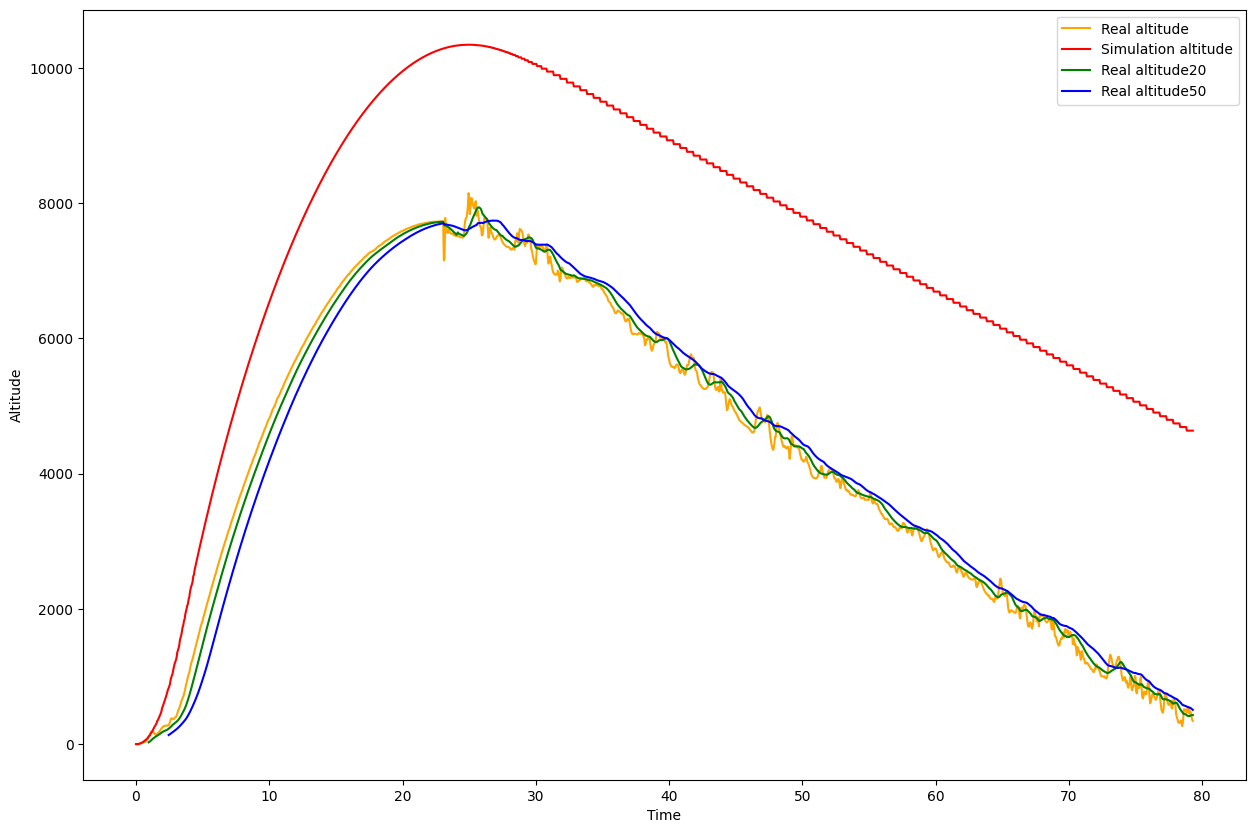

In [34]:
plt.figure(figsize=(15,10))

# Media movil 20 (hay 20 datos por segundo)
df_media_movil20 = pd.DataFrame(df['Altitude'].rolling(window=20).mean()).rename(columns={'Altitude':'Real altitude20'})

# Media movil 50
df_media_movil50 = pd.DataFrame(df['Altitude'].rolling(window=50).mean()).rename(columns={'Altitude':'Real altitude50'})

sns.lineplot(data=df, x='Time', y='Altitude', color='orange', label='Real altitude')
sns.lineplot(data=df, x='Time', y='Simulation altitude', color='red', label='Simulation altitude')
sns.lineplot(data=pd.concat([df, df_media_movil20], axis=1), x='Time', y='Real altitude20', color='green', label='Real altitude20')
sns.lineplot(data=pd.concat([df, df_media_movil50], axis=1), x='Time', y='Real altitude50', color='blue', label='Real altitude50')

plt.legend()

Seguimos con altura, solo los 10 primeros segundos

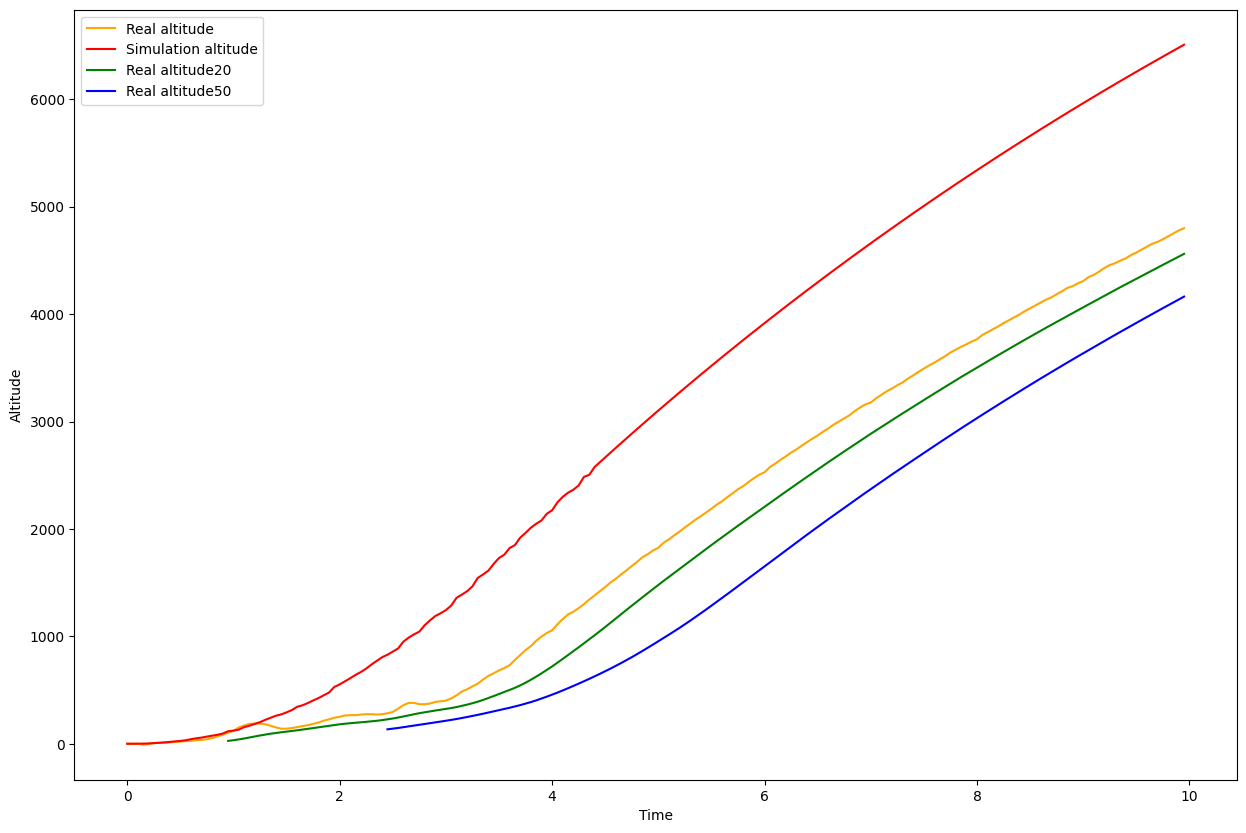

In [35]:
plt.figure(figsize=(15,10))

# Condicion Time
df_conditioned_altitude = df[df['Time']<10]

# Media movil 20 (hay 20 datos por segundo)
df_conditioned_altitude_media_movil20 = pd.DataFrame(df_conditioned_altitude['Altitude'].rolling(window=20).mean()).rename(columns={'Altitude':'Real altitude20'})

# Media movil 50
df_conditioned_altitude_media_movil50 = pd.DataFrame(df_conditioned_altitude['Altitude'].rolling(window=50).mean()).rename(columns={'Altitude':'Real altitude50'})

sns.lineplot(data=df_conditioned_altitude, x='Time', y='Altitude', color='orange', label='Real altitude')
sns.lineplot(data=df_conditioned_altitude, x='Time', y='Simulation altitude', color='red', label='Simulation altitude')
sns.lineplot(data=pd.concat([df_conditioned_altitude, df_conditioned_altitude_media_movil20], axis=1), x='Time', y='Real altitude20', color='green', label='Real altitude20')
sns.lineplot(data=pd.concat([df_conditioned_altitude, df_conditioned_altitude_media_movil50], axis=1), x='Time', y='Real altitude50', color='blue', label='Real altitude50')

plt.legend()

Calculamos la pendiente de cada punto de altura real y simulada

In [65]:
# Calculamos la pendiente de cada punto de altitud

inicio = df.loc[0,['Time','Altitude']].values
df.loc[0,'Pendiente_real'] = 0
for pos in range(1,len(df)):
  dupla = df.loc[pos, ['Time','Altitude']].values
  pendiente = (dupla[1]-inicio[1])/(dupla[0]-inicio[0])

  df.loc[pos, 'Pendiente_real'] = pendiente
  inicio = dupla

# Calculamos pendiente con diff. -> da lo mismo que arriba
# df['Pendiente_diff'] = df['Altitude'].diff()/df['Time'].diff()

In [69]:
# Calculamos la pendiente de cada punto de altitud simulada

inicio = df.loc[0,['Time','Simulation altitude']].values
df.loc[0,'Pendiente_sim'] = 0
for pos in range(1,len(df)):
  dupla = df.loc[pos, ['Time','Simulation altitude']].values
  pendiente = (dupla[1]-inicio[1])/(dupla[0]-inicio[0])

  df.loc[pos, 'Pendiente_sim'] = pendiente
  inicio = dupla

# Calculamos pendiente con diff. -> da lo mismo que arriba
# df['Pendiente_diff'] = df['Simulation altitude'].diff()/df['Time'].diff()

El maximo de altitud ocurre en el segundo 24,95. El maximo real ocurre en el mismo punto donde deberia ocurrir el maximo simulado

In [77]:
max_altura_real = df[df['Altitude']==df['Altitude'].max()]
max_altura_sim = df[df['Simulation altitude']==df['Simulation altitude'].max()]

In [85]:
(max_altura_real.index == max_altura_sim.index)

array([ True])

In [86]:
max_altura_real

,Time,Altitude,Velocity,Simulation altitude,Simulation Velocity [m/s],Simulation Velocity [ft/s],Smoothing (H),Smoothing (V),Error Parachute,Pendiente,Pendiente_diff,Pendiente_real,Pendiente_sim
499,24.95,8145.261,591.8095,10340.809,-0.004,-0.013124,7653.699107,50.740371,0.0,3891.14,3891.14,3891.14,0.76


Analisis de pendientes (previo al maximo)

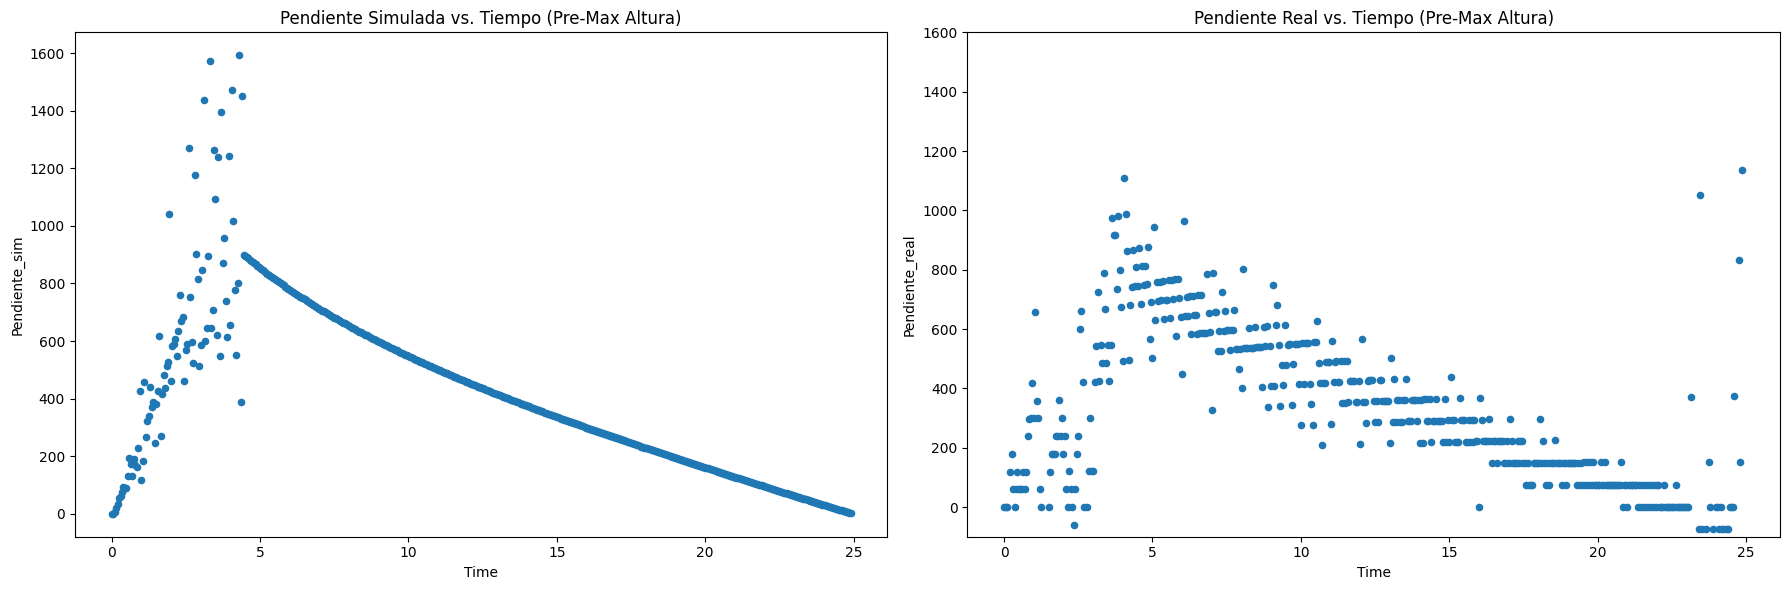

In [99]:
import matplotlib.pyplot as plt

# Filter data to only include points before the maximum altitude
df_before_max = df[df['Time'] < max_altura_real['Time'].values[0]]

fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # 1 row, 2 columns

# Plot Pendiente_sim on the first subplot
df_before_max.plot(kind='scatter', x='Time', y='Pendiente_sim', ax=axes[0], title='Pendiente Simulada vs. Tiempo (Pre-Max Altura)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Pendiente_sim')

# Plot Pendiente_real on the second subplot
df_before_max.plot(kind='scatter', x='Time', y='Pendiente_real', ax=axes[1], title='Pendiente Real vs. Tiempo (Pre-Max Altura)')
axes[1].set_ylim(-100, 1600)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Pendiente_real')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

In [120]:
outliers = df_before_max[(df['Pendiente_real'] < -100) | (df['Pendiente_real'] > 1600)]
outliers_severos = outliers[abs(outliers['Pendiente_real']) > 5000]

/tmp/ipython-input-3588789934.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = df_before_max[(df['Pendiente_real'] < -100) | (df['Pendiente_real'] > 1600)]


<Axes: xlabel='Time', ylabel='Pendiente_real'>

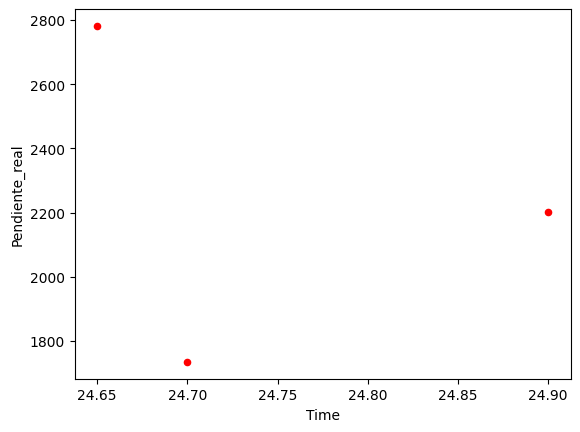

In [121]:
outliers[~outliers.isin(outliers_severos)][outliers['Pendiente_real'] > 0].dropna().plot(kind='scatter', x='Time', y='Pendiente_real', color='red')

<Axes: xlabel='Time', ylabel='Pendiente_real'>

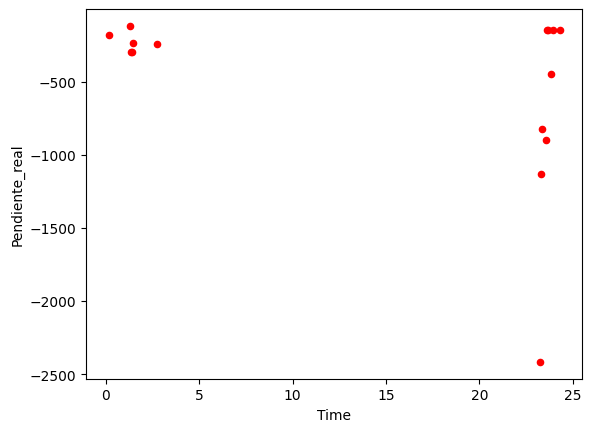

In [122]:
outliers[~outliers.isin(outliers_severos)][outliers['Pendiente_real'] < 0].dropna().plot(kind='scatter', x='Time', y='Pendiente_real', color='red')

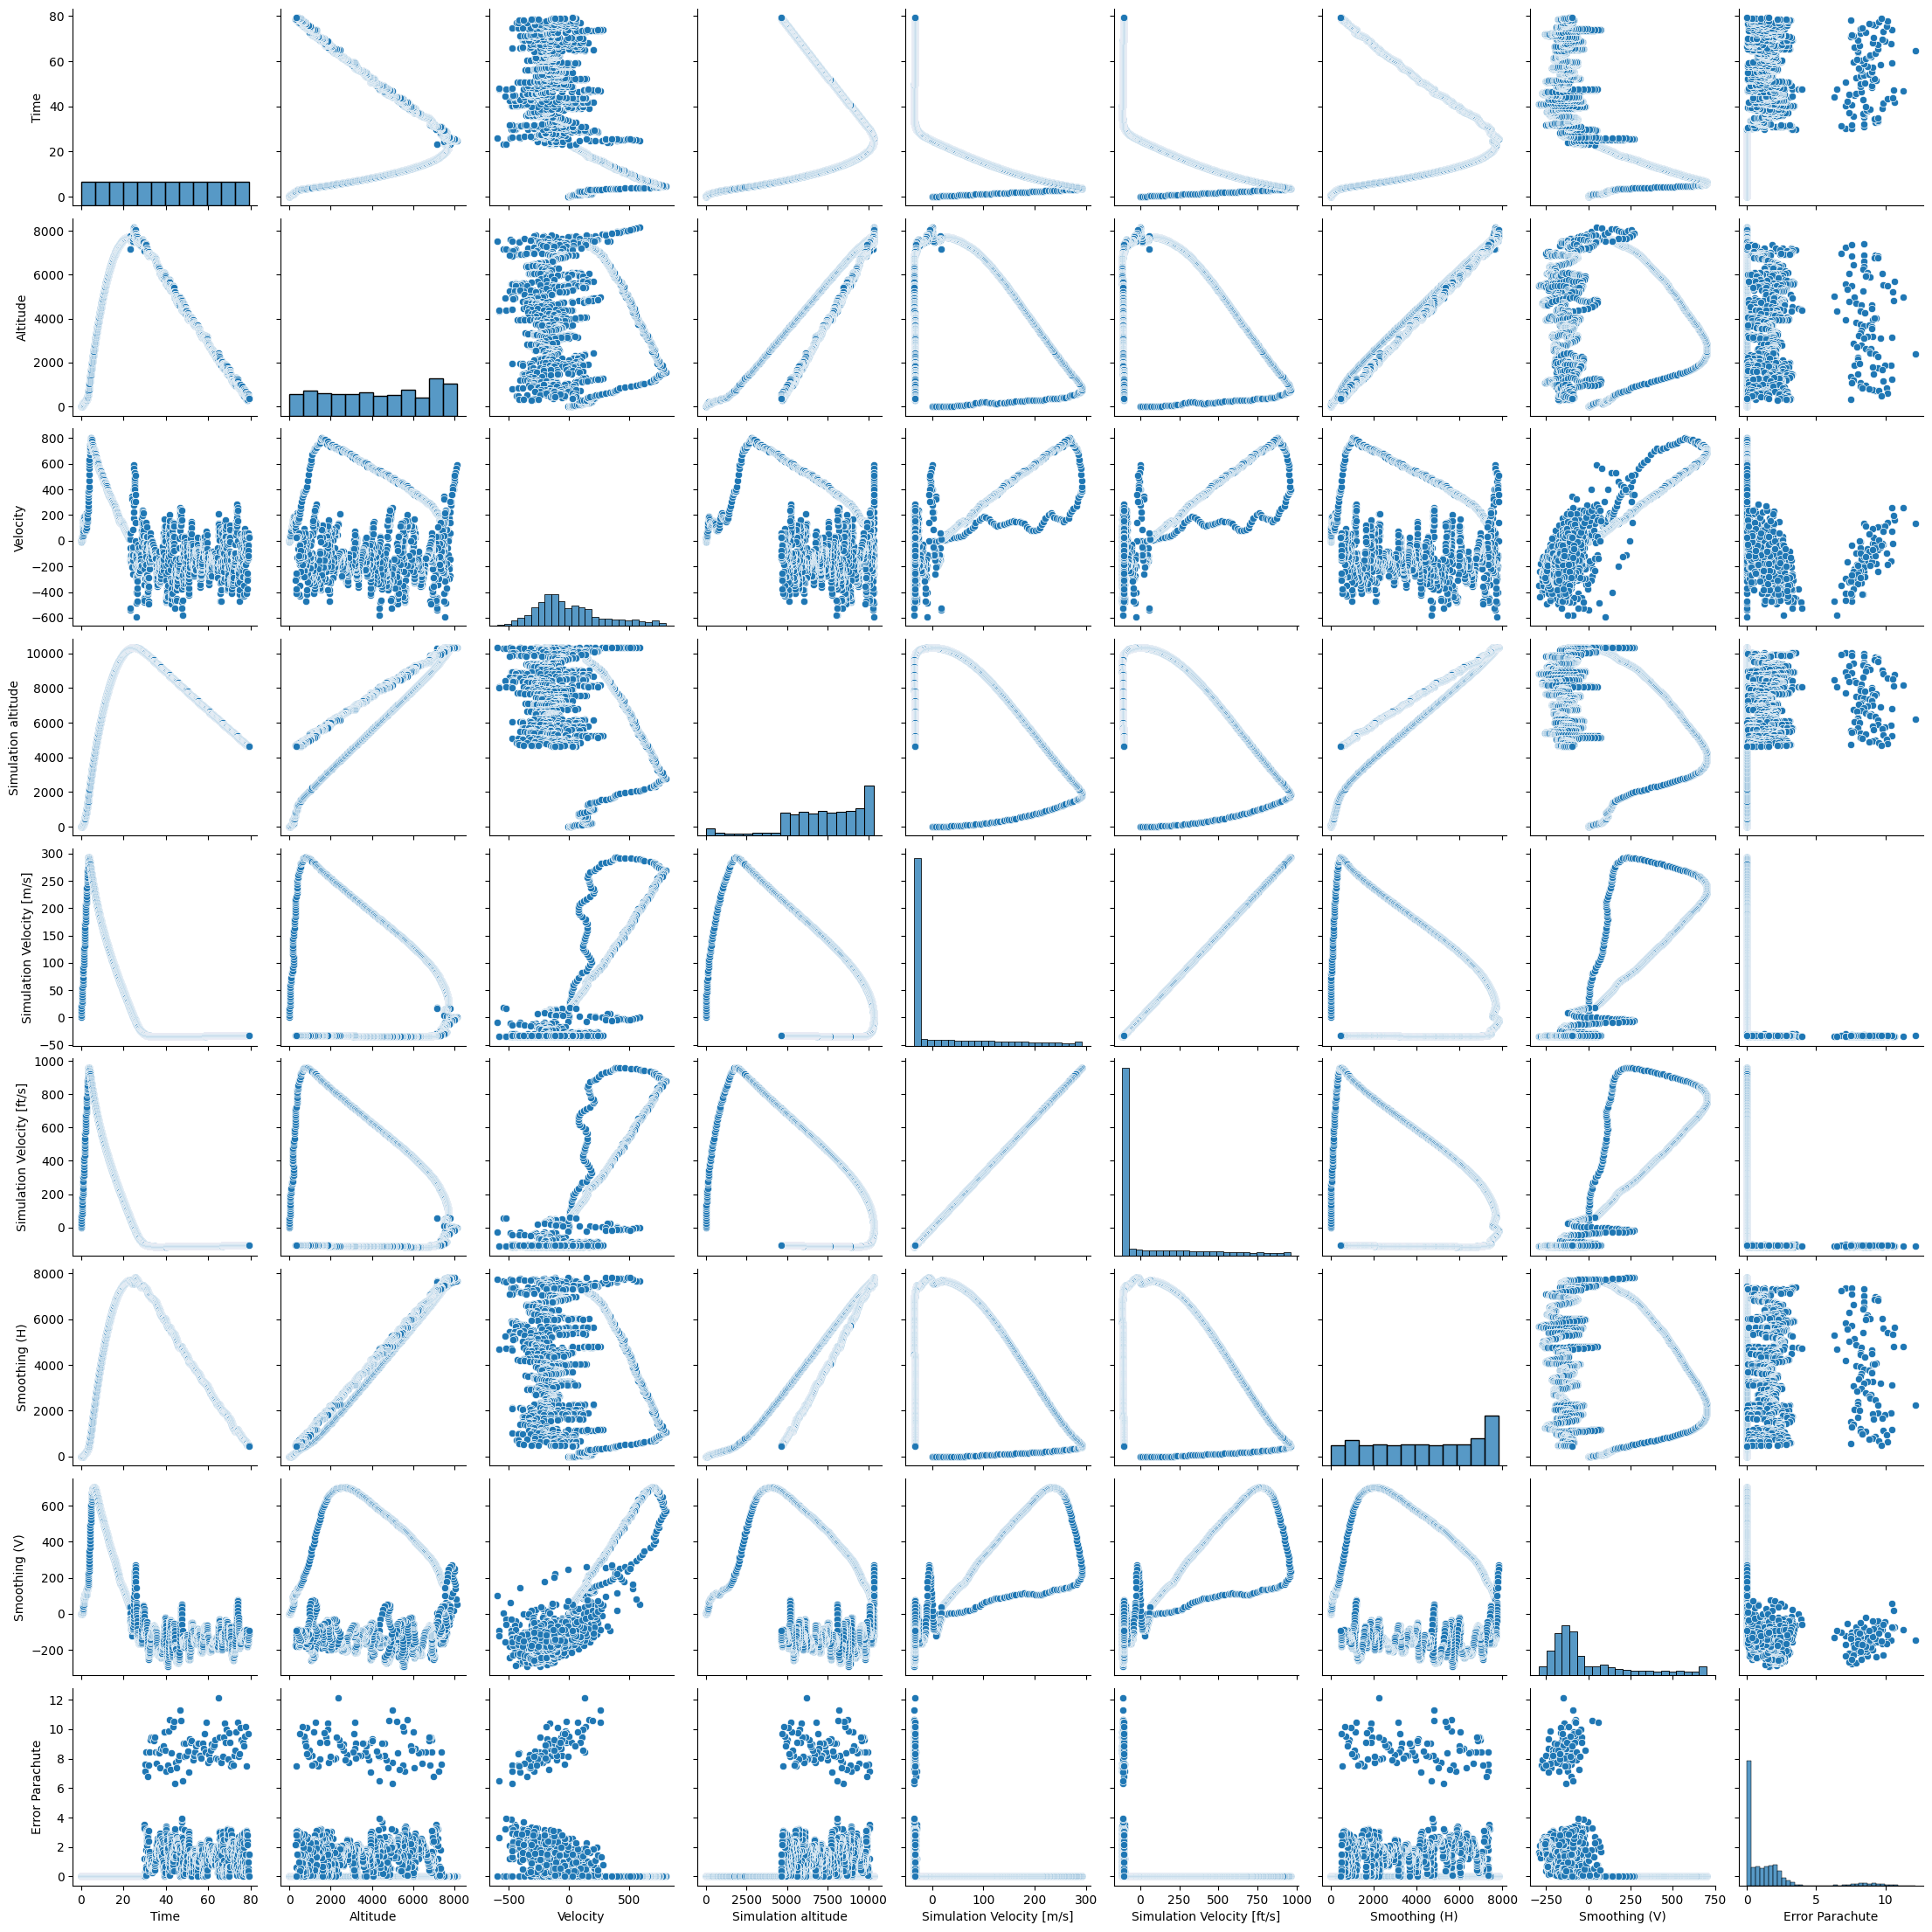

In [18]:
sns.pairplot(df)